In [92]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
import numpy as np
import torch
from bgflow import MultiDoubleWellPotential
from bgflow.utils import remove_mean

In [94]:
import os
import sys

# Get the absolute path to the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add the parent directory to sys.path if it's not already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from src.utils.dw4_plots import distance_histogram, energy_histogram

# Now you can import modules from the source/ directory
from src.utils.tbg_utils import kish_effective_sample_size

## Define target

In [95]:
# first define system dimensionality and a target energy/distribution

dim = 8
n_particles = 4
n_dimensions = dim // n_particles

# DW parameters
a = 0.9
b = -4
c = 0
offset = 4

target = MultiDoubleWellPotential(dim, n_particles, a, b, c, offset, two_event_dims=False)

## Load data

In [96]:
# define a MCMC sampler to sample from the target energy

dw4_data = np.load("/Users/chatan/fast-tbg/data/dw4-dataidx.npy", allow_pickle=True)
all_data = remove_mean(dw4_data[0], n_particles, n_dimensions)
idx = dw4_data[1]
data = all_data[idx[:100000]]
val_data = all_data[idx[100000:500000]]
data_holdout = all_data[idx[-500000:]]

In [97]:
# define paths
run = "2025-01-08_12-39-21"
DATA_PATH = f"/Users/chatan/fast-tbg/logs/eval/runs/{run}/npy_outputs"

# load samples
samples_proposal = torch.tensor(np.load(DATA_PATH + "/samples_proposal.npy"))
log_p_proposal = torch.tensor(np.load(DATA_PATH + "/log_p_proposal.npy"))

# destandardize samples
samples_proposal = samples_proposal.view(-1, 4, 2)
samples_proposal *= torch.tensor([1.8230, 1.8103])
samples_proposal = samples_proposal.view(-1, 8)

print(samples_proposal.shape)

torch.Size([1000, 8])


## Compute importance weights

In [98]:
# compute importance weights

logits = -target.energy(samples_proposal).flatten() + log_p_proposal.flatten()
max_logits = torch.max(logits)
importance_weights = torch.nn.functional.softmax(logits - max_logits)

/var/folders/gc/0119ch550jvf4tpgb_30d6hr0000gr/T/ipykernel_3039/2908558706.py:5: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  importance_weights = torch.nn.functional.softmax(logits - max_logits)


## ESS

In [99]:
print(kish_effective_sample_size(importance_weights) / len(importance_weights))

tensor(0.0954)


## Energy histogram

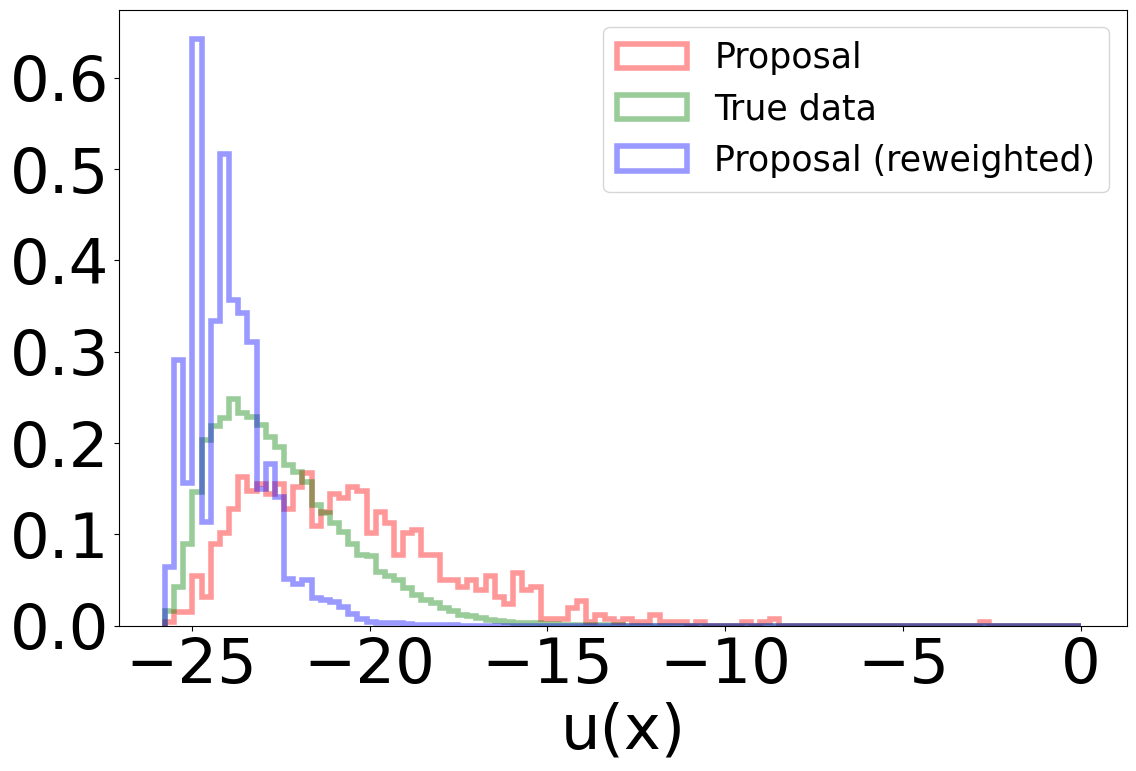

In [ ]:
energy_histogram(samples_proposal, importance_weights)

## Distance histogram

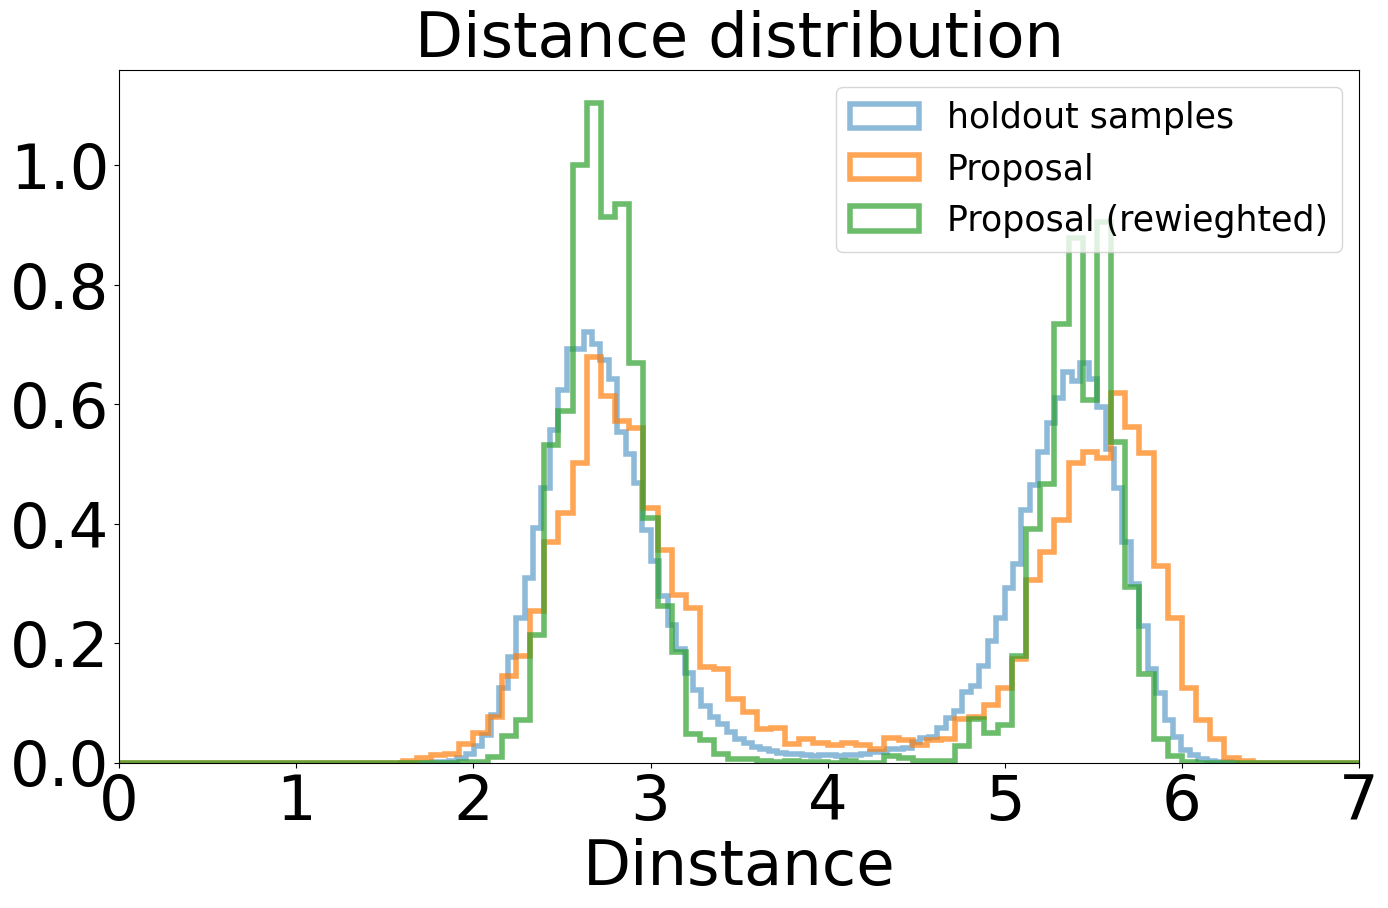

In [91]:
distance_histogram(data_holdout, samples_proposal, importance_weights)